# Reto 01: Simulador de máquinas — K-Armed Bandit

**Curso:** Aprendizaje por refuerzo — Sesión 1
**Profesor:** Juan Camilo Tejada Orjuela, Ph.D.(C) — Universidad EIA

**Integrante:** Nicolás Ochoa Valencia
**Correo institucional:** _[completar correo institucional]_
**Fecha de entrega:** 2026-07-25

> ⚠️ Antes de entregar: reemplaza el correo institucional por el real, ajusta la fecha si es necesario y agrega aquí a los demás integrantes del equipo (nombre y correo) si el reto se realizó en grupo.

## Objetivo del notebook
Construir un simulador de un problema K-Armed Bandit con 3 máquinas tragamonedas de distribución normal, simular 1,000 recompensas por máquina, calcular sus estadísticas muestrales (media, desviación estándar y varianza), comparar los valores **reales** vs. los **estimados**, graficar las distribuciones, analizar por qué la máquina $A_3$ es más riesgosa, y estudiar cómo el tamaño de muestra afecta la calidad de las estimaciones.

## Descripción del problema

| Máquina $(a)$ | Distribución | $\mu$ (real) | $\sigma$ (real) |
|:---:|:---:|:---:|:---:|
| $A_1$ | Normal | 1.0 | 0.5 |
| $A_2$ | Normal | **2.0** | 0.5 |
| $A_3$ | Normal | 1.5 | **1.5** |

El valor real de cada acción es $Q^*(a) = \mathbb{E}[R_t \mid A_t = a] = \mu$. El agente **no conoce** este valor: solo puede estimarlo muestreando, es decir, $Q_t(a) \approx Q^*(a)$.

**Pregunta guía:** si no conocemos la recompensa media de cada máquina, ¿cómo podemos estimar cuál máquina conviene elegir?

## 1. Configuración e importaciones

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Semilla para que los resultados sean reproducibles
SEED = 42
rng = np.random.default_rng(SEED)

## 2. Definición de las máquinas

Cada máquina se representa con sus dos parámetros reales, que el agente **no** conoce de antemano:

- **`mean`** ($\mu$): la recompensa promedio real de la máquina a largo plazo, es decir $Q^*(a) = \mathbb{E}[R_t \mid A_t = a]$. Es el número que quisiéramos conocer para decidir cuál máquina jugar siempre.
- **`std`** ($\sigma$): la desviación estándar real de la máquina. Mide qué tanto varían las recompensas individuales alrededor de la media: un `std` bajo produce recompensas consistentes y cercanas a $\mu$; un `std` alto produce recompensas muy dispersas, algunas muy por encima y otras muy por debajo de $\mu$.

**¿Por qué dos máquinas con medias similares pueden producir resultados diferentes?** Porque la media solo describe el promedio a largo plazo, no el comportamiento de una sola jugada. Por ejemplo, $A_1$ ($\mu=1.0$) y $A_3$ ($\mu=1.5$) tienen medias relativamente cercanas, pero $A_3$ tiene un `std` tres veces mayor. Eso significa que una sola recompensa de $A_3$ puede terminar muy por debajo o muy por encima de $A_1$, aunque en promedio (con muchas jugadas) $A_3$ sea ligeramente mejor. En otras palabras, **media similar no implica comportamiento similar** si las varianzas son distintas.

In [2]:
MACHINES = {
    "A1": {"mean": 1.0, "std": 0.5},
    "A2": {"mean": 2.0, "std": 0.5},
    "A3": {"mean": 1.5, "std": 1.5},
}
MACHINES

{'A1': {'mean': 1.0, 'std': 0.5},
 'A2': {'mean': 2.0, 'std': 0.5},
 'A3': {'mean': 1.5, 'std': 1.5}}

## 3. Función `reward(arm)`

Cada vez que "jalamos un brazo", la recompensa $R$ es un valor aleatorio extraído de la distribución normal $N(\mu, \sigma)$ de esa máquina. La distribución es la "verdad oculta" que el agente no conoce. La función también debe fallar de forma clara si se le pide una máquina que no existe.

In [3]:
def reward(arm: str) -> float:
    """Entrega una recompensa aleatoria según la distribución
    normal de la máquina indicada.

    Parámetros
    ----------
    arm : str
        Nombre de la máquina: 'A1', 'A2' o 'A3'.

    Retorna
    -------
    float
        Recompensa muestreada de N(mean, std).

    Lanza
    -----
    ValueError
        Si `arm` no corresponde a ninguna máquina definida en MACHINES.
    """
    if arm not in MACHINES:
        raise ValueError(
            f"La máquina '{arm}' no existe. Máquinas válidas: {list(MACHINES.keys())}"
        )
    params = MACHINES[arm]
    return float(rng.normal(loc=params["mean"], scale=params["std"]))

# Prueba rápida: jalar una vez cada brazo
for arm in MACHINES:
    print(f"{arm}: recompensa de ejemplo = {reward(arm):.4f}")

A1: recompensa de ejemplo = 1.1524
A2: recompensa de ejemplo = 1.4800
A3: recompensa de ejemplo = 2.6257


In [4]:
# Prueba de manejo de errores: pedir una máquina que no existe
try:
    reward("A9")
except ValueError as e:
    print(f"Error capturado correctamente: {e}")

Error capturado correctamente: La máquina 'A9' no existe. Máquinas válidas: ['A1', 'A2', 'A3']


## 4. Simulación de 1,000 recompensas por máquina

Se construye un `DataFrame` con una fila por observación (`machine`, `sample`, `reward`), de forma que el resultado completo tenga **3,000 registros** (3 máquinas × 1,000 recompensas).

In [5]:
N_SAMPLES = 1_000

rows = []
for arm in MACHINES:
    for i in range(1, N_SAMPLES + 1):
        rows.append({"machine": arm, "sample": i, "reward": reward(arm)})

df_rewards = pd.DataFrame(rows)
df_rewards.head()

,machine,sample,reward
0,A1,1,1.470282
1,A1,2,0.024482
2,A1,3,0.348910
3,A1,4,1.063920
4,A1,5,0.841879


In [6]:
# Verificaciones explícitas de la simulación
print("Observaciones por máquina:")
print(df_rewards["machine"].value_counts(), "\n")

print("Total de observaciones:", len(df_rewards))
assert len(df_rewards) == 3 * N_SAMPLES, "Se esperaban 3,000 registros en total"

print("\nValores faltantes por columna:")
print(df_rewards.isna().sum())
assert df_rewards.isna().sum().sum() == 0, "No deberían existir valores faltantes"

print("\nTipos de datos:")
print(df_rewards.dtypes)

Observaciones por máquina:
machine
A1    1000
A2    1000
A3    1000
Name: count, dtype: int64 

Total de observaciones: 3000

Valores faltantes por columna:
machine    0
sample     0
reward     0
dtype: int64

Tipos de datos:
machine        str
sample       int64
reward     float64
dtype: object


## 5. Estadísticos descriptivos

Para cada máquina se calculan la media, desviación estándar, varianza (muestrales, con `ddof=1`), mínimo y máximo, y se comparan contra los parámetros reales.

In [7]:
summary_rows = []
for arm, params in MACHINES.items():
    r = df_rewards.loc[df_rewards["machine"] == arm, "reward"]
    media_est = r.mean()
    summary_rows.append({
        "Máquina": arm,
        "Media real": params["mean"],
        "Media estimada": media_est,
        "Error absoluto de la media": abs(media_est - params["mean"]),
        "Desviación real": params["std"],
        "Desviación estimada": r.std(ddof=1),
        "Varianza estimada": r.var(ddof=1),
        "Mínimo": r.min(),
        "Máximo": r.max(),
    })

df_summary = pd.DataFrame(summary_rows).round(4)
df_summary

,Máquina,Media real,Media estimada,Error absoluto de la media,Desviación real,Desviación estimada,Varianza estimada,Mínimo,Máximo
0,A1,1.0,0.9849,0.0151,0.5,0.4943,0.2444,-0.8242,2.5894
1,A2,2.0,1.9596,0.0404,0.5,0.5073,0.2574,0.4762,3.4571
2,A3,1.5,1.5574,0.0574,1.5,1.5285,2.3364,-3.0957,6.0893


> **Nota:** usamos `ddof=1` para la varianza y desviación estándar **muestrales** (divide entre $n-1$ en lugar de $n$), que es el estimador insesgado cuando trabajamos con una muestra y no con toda la población.

## 6. Visualizaciones

Una gráfica por máquina: histograma de recompensas, con la media real y la media estimada marcadas, y los mismos límites del eje horizontal para poder comparar directamente.

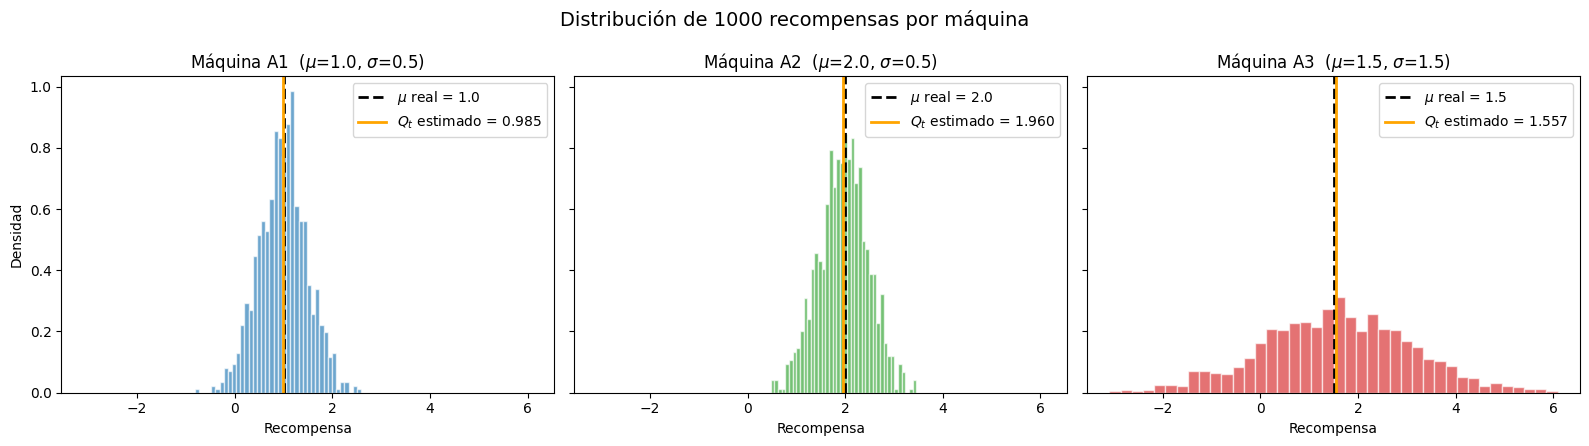

In [8]:
colores = {"A1": "#1f77b4", "A2": "#2ca02c", "A3": "#d62728"}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)

for ax, arm in zip(axes, MACHINES):
    r = df_rewards.loc[df_rewards["machine"] == arm, "reward"]
    fila = df_summary.loc[df_summary["Máquina"] == arm].iloc[0]

    ax.hist(r, bins=40, density=True, alpha=0.65, color=colores[arm], edgecolor="white")
    ax.axvline(fila["Media real"], color="black", linestyle="--", linewidth=2,
               label=f"$\\mu$ real = {fila['Media real']}")
    ax.axvline(fila["Media estimada"], color="orange", linestyle="-", linewidth=2,
               label=f"$Q_t$ estimado = {fila['Media estimada']:.3f}")
    ax.set_title(f"Máquina {arm}  ($\\mu$={MACHINES[arm]['mean']}, $\\sigma$={MACHINES[arm]['std']})")
    ax.set_xlabel("Recompensa")
    ax.legend()

axes[0].set_ylabel("Densidad")
plt.suptitle(f"Distribución de {N_SAMPLES} recompensas por máquina", fontsize=14)
plt.tight_layout()
plt.show()

### Comparación de las tres máquinas en una sola gráfica

Superponer las curvas permite ver directamente el dilema exploración vs. explotación: $A_2$ domina en promedio, pero $A_3$ tiene colas mucho más anchas.

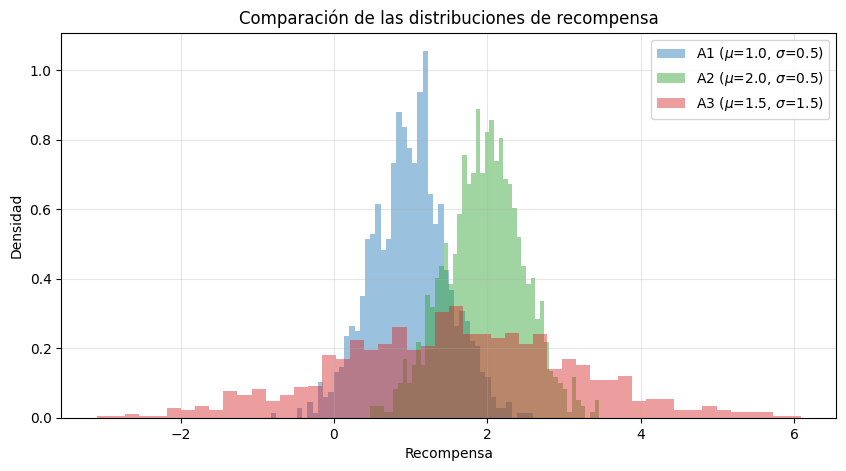

In [9]:
plt.figure(figsize=(10, 5))

for arm in MACHINES:
    r = df_rewards.loc[df_rewards["machine"] == arm, "reward"]
    plt.hist(r, bins=50, density=True, alpha=0.45,
             label=f"{arm} ($\\mu$={MACHINES[arm]['mean']}, $\\sigma$={MACHINES[arm]['std']})",
             color=colores[arm])

plt.title("Comparación de las distribuciones de recompensa")
plt.xlabel("Recompensa")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Extra: cómo converge la estimación con el promedio incremental

La fórmula vista en clase actualiza la estimación con cada nueva recompensa:

$$Q_{t+1}(a) = Q_t(a) + \frac{1}{n_t(a)}\left(R_{t+1} - Q_t(a)\right)$$

Grafiquemos cómo $Q_t(a)$ se acerca a $Q^*(a)$ a medida que aumentan las jugadas.

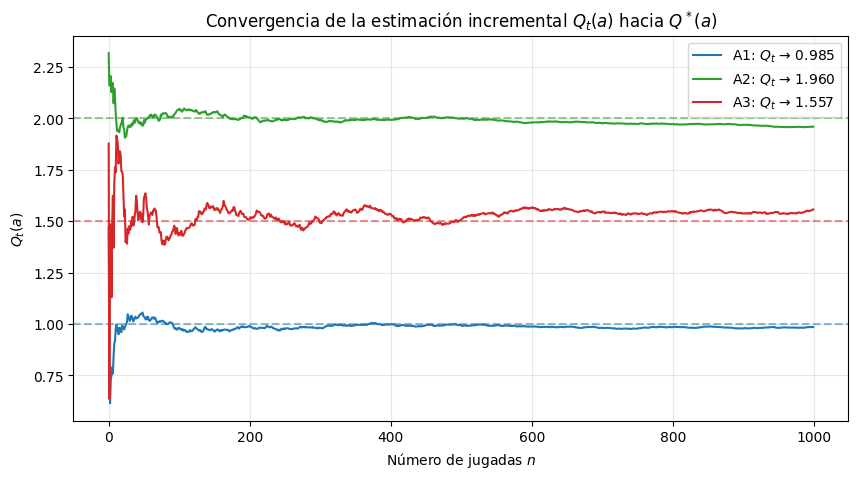

In [10]:
plt.figure(figsize=(10, 5))

for arm in MACHINES:
    r = df_rewards.loc[df_rewards["machine"] == arm, "reward"].to_numpy()
    Q = np.zeros(N_SAMPLES)
    q = 0.0
    for n, R in enumerate(r, start=1):
        q = q + (1 / n) * (R - q)
        Q[n - 1] = q
    plt.plot(Q, color=colores[arm], label=f"{arm}: $Q_t$ → {Q[-1]:.3f}")
    plt.axhline(MACHINES[arm]["mean"], color=colores[arm], linestyle="--", alpha=0.5)

plt.title("Convergencia de la estimación incremental $Q_t(a)$ hacia $Q^*(a)$")
plt.xlabel("Número de jugadas $n$")
plt.ylabel("$Q_t(a)$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Riesgo de $A_3$: evidencia numérica

Aunque su media ($\mu=1.5$) es mayor que la de $A_1$, su desviación estándar ($\sigma=1.5$) es 3 veces mayor que la de $A_1$ y $A_2$. Esto se traduce en un rango de recompensas mucho más amplio y en una cantidad notable de recompensas negativas.

In [11]:
for arm in MACHINES:
    r = df_rewards.loc[df_rewards["machine"] == arm, "reward"]
    negativas = (r < 0).sum()
    print(f"{arm}: mín = {r.min():>7.3f} | máx = {r.max():>7.3f} | "
          f"rango = {r.max() - r.min():>7.3f} | recompensas negativas = {negativas} de {N_SAMPLES}")

A1: mín =  -0.824 | máx =   2.589 | rango =   3.414 | recompensas negativas = 24 de 1000
A2: mín =   0.476 | máx =   3.457 | rango =   2.981 | recompensas negativas = 0 de 1000
A3: mín =  -3.096 | máx =   6.089 | rango =   9.185 | recompensas negativas = 143 de 1000


## 7. Interpretación

Las respuestas siguientes están sustentadas en los resultados de la ejecución con `SEED = 42` (tabla de la sección 5 y gráficas de la sección 6).

**1. ¿Cuál máquina tuvo la mayor recompensa media estimada?**
$A_2$, con una media estimada de aproximadamente 1.96 (ver `df_summary`).

**2. ¿La máquina con mayor media estimada coincide con la de mayor media real?**
Sí. $A_2$ también tiene la mayor media real ($\mu=2.0$). La estimación con 1,000 muestras identificó correctamente a la mejor máquina.

**3. ¿Cuál máquina presentó mayor desviación y varianza?**
$A_3$, tanto en desviación estándar (~1.53 estimada vs. 0.49–0.51 de $A_1$ y $A_2$) como en varianza (~2.33 estimada, casi 9 veces la de las otras dos).

**4. ¿Por qué $A_3$ puede considerarse más riesgosa?**
Porque, aunque su media (1.5) es intermedia, su alta dispersión hace que las recompensas individuales varíen mucho: en esta simulación $A_3$ llegó a producir recompensas negativas en 143 de 1,000 jugadas (frente a 24 de $A_1$ y 0 de $A_2$) y también las recompensas más altas de las tres máquinas (máximo ≈ 6.09). Confiar en $A_3$ implica aceptar una mayor incertidumbre en el resultado de cada jugada individual, aunque el promedio a largo plazo sea razonable.

**5. ¿Una recompensa ocasionalmente alta implica que una máquina sea la mejor?**
No. Una recompensa alta puntual puede ser simplemente una muestra extrema de una distribución con mucha varianza (como $A_3$), no una señal de que esa máquina tenga la mejor media real. Decidir con base en una sola observación (o pocas) puede llevar a elegir la máquina equivocada.

**6. ¿Qué puede ocurrir si se estima la media utilizando pocas observaciones?**
El estimador $Q_t(a)$ puede alejarse bastante del valor real $Q^*(a)$, especialmente en máquinas con `std` alto. Con pocas muestras el error de estimación es más grande y más variable (ver sección 8): el agente corre el riesgo de descartar una buena máquina o sobrestimar una mala solo por el azar de las primeras jugadas.

**7. Si las medias reales fueran desconocidas, ¿qué información utilizarías para decidir cuál máquina elegir?**
Usaría la media muestral acumulada $Q_t(a)$ de cada máquina como mejor estimador disponible de $Q^*(a)$, actualizada de forma incremental con cada nueva jugada, y complementaría la decisión con el número de veces que se ha probado cada máquina (para saber qué tan confiable es esa estimación) y con la varianza muestral (para dimensionar el riesgo). Esto es justamente el problema de exploración vs. explotación: jugar lo suficiente en cada máquina antes de confiar plenamente en su $Q_t(a)$.

**8. ¿Cómo cambiarían tus conclusiones con solo 10 recompensas por máquina?**
Con `n=10` las estimaciones son mucho más ruidosas (ver sección 8): en esta ejecución, con 10 muestras $A_1$ se estimó en 0.83 (error de 0.17 frente al real de 1.0), mientras que con 1,000 muestras el error baja a 0.01. Con muestras tan pequeñas no se puede confiar en que la máquina con mayor $Q_t(a)$ observado sea realmente la mejor; se necesitarían más jugadas (más exploración) antes de tomar una decisión firme.

## 8. Experimento adicional: efecto del tamaño de muestra

Se repite la estimación de la media usando solo las primeras 10, 50, 100 y 1,000 observaciones de cada máquina (mismos datos ya generados en la sección 4, tomando prefijos crecientes), para ver cómo se comporta $Q_t(a)$ a medida que el agente acumula experiencia.

In [12]:
sample_sizes = [10, 50, 100, 1000]
rows8 = []
for n in sample_sizes:
    for arm, params in MACHINES.items():
        r = df_rewards.loc[df_rewards["machine"] == arm, "reward"].to_numpy()[:n]
        rows8.append({
            "Tamaño de muestra": n,
            "Máquina": arm,
            "Media real": params["mean"],
            "Media estimada": r.mean(),
            "Error absoluto": abs(r.mean() - params["mean"]),
        })

df_sample_sizes = pd.DataFrame(rows8).round(4)

# Tabla comparativa: media estimada de cada máquina para cada tamaño de muestra
tabla_comparativa = df_sample_sizes.pivot(index="Máquina", columns="Tamaño de muestra", values="Media estimada")
tabla_comparativa

Tamaño de muestra,10,50,100,1000
Máquina,,,,
A1,0.9176,1.0401,0.9776,0.9849
A2,2.1057,1.9667,2.0441,1.9596
A3,1.7626,1.5298,1.4311,1.5574


In [13]:
# Error absoluto para cada combinación de máquina y tamaño de muestra
tabla_error = df_sample_sizes.pivot(index="Máquina", columns="Tamaño de muestra", values="Error absoluto")
tabla_error

Tamaño de muestra,10,50,100,1000
Máquina,,,,
A1,0.0824,0.0401,0.0224,0.0151
A2,0.1057,0.0333,0.0441,0.0404
A3,0.2626,0.0298,0.0689,0.0574


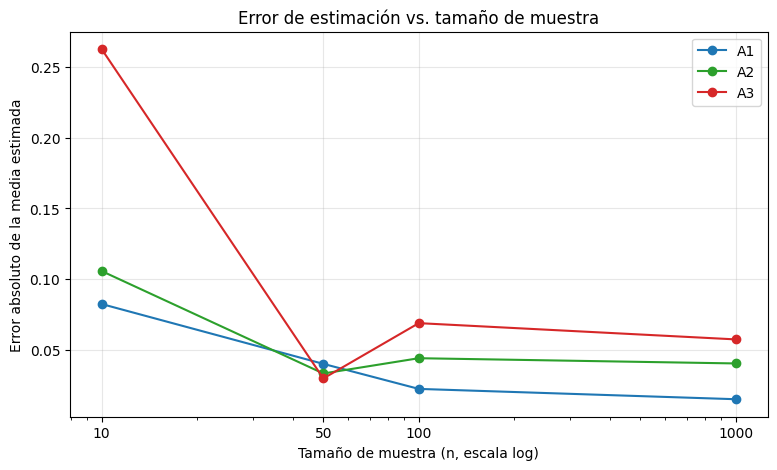

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
for arm, params in MACHINES.items():
    errores = [df_sample_sizes.loc[(df_sample_sizes["Máquina"] == arm) & (df_sample_sizes["Tamaño de muestra"] == n),
                                    "Error absoluto"].values[0] for n in sample_sizes]
    ax.plot(sample_sizes, errores, marker="o", color=colores[arm], label=arm)

ax.set_xscale("log")
ax.set_xticks(sample_sizes)
ax.set_xticklabels(sample_sizes)
ax.set_xlabel("Tamaño de muestra (n, escala log)")
ax.set_ylabel("Error absoluto de la media estimada")
ax.set_title("Error de estimación vs. tamaño de muestra")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

**Análisis:**

- **Cómo cambia la estimación al aumentar el número de observaciones:** en general el error absoluto tiende a reducirse y a estabilizarse a medida que crece `n`, ya que el estimador $Q_t(a)$ se acerca a $Q^*(a)$ por la ley de los grandes números. Con `n=10` los errores pueden ser grandes o pequeños casi por azar; con `n=1000` los tres quedan en un rango pequeño y consistente.
- **En qué máquina parece haber mayor inestabilidad:** en esta ejecución puntual, $A_1$ mostró el mayor error con solo 10 muestras (0.17), pero el argumento teórico más robusto es otro: el error estándar de la media es $\sigma/\sqrt{n}$, por lo que, para un mismo `n`, $A_3$ (con $\sigma=1.5$, tres veces mayor que $A_1$ y $A_2$) tiene el mayor error estándar esperado y por tanto la mayor inestabilidad **en promedio** si el experimento se repitiera muchas veces con distintas semillas. Una sola ejecución no siempre lo deja ver, pero es lo que predice la teoría.
- **Por qué una mayor variabilidad dificulta la estimación:** cuando `std` es alto, cada observación individual aporta menos información sobre la verdadera media, porque puede estar muy lejos de ella solo por azar. Se necesitan más muestras para que esas desviaciones se cancelen entre sí (promediarse) y la estimación converja; con pocas muestras, una máquina de alta varianza como $A_3$ puede parecer mucho mejor o mucho peor de lo que realmente es.

## 9. Uso de inteligencia artificial

_(Completa/ajusta esta sección con honestidad según el trabajo real del equipo; el siguiente texto es un punto de partida basado en el desarrollo de este notebook.)_

**Herramienta utilizada:**
Claude (Anthropic), a través de la interfaz de chat.

**Prompts o preguntas principales:**
1. "Ayúdame a construir un simulador de un problema K-Armed Bandit con 3 máquinas de distribución normal, generando 1,000 recompensas por máquina en un DataFrame de pandas."
2. "¿Cómo agrego una línea vertical con la media real y otra con la media estimada en un histograma de Matplotlib, con leyenda?"
3. "¿Cómo comparo el efecto del tamaño de muestra (10, 50, 100, 1000) sobre el error de estimación de la media?"

**Recomendaciones recibidas:**
- Usar `np.random.default_rng(SEED)` en vez de `np.random.seed` para generación reproducible y más moderna.
- Estructurar la simulación como un `DataFrame` largo (`machine`, `sample`, `reward`) en lugar de arreglos sueltos, para facilitar filtros y agregaciones con pandas.
- Usar `ax.axvline(...)` para marcar la media real y la media estimada en cada histograma.
- Calcular el error estándar teórico ($\sigma/\sqrt{n}$) para explicar por qué una máquina con mayor `std` debería mostrar mayor inestabilidad al variar el tamaño de muestra.

**Ajustes realizados manualmente:**
- Se agregó el manejo explícito de error (`ValueError`) en `reward(arm)` para máquinas inexistentes, con un mensaje claro.
- Se agregaron las verificaciones explícitas de la simulación (conteo por máquina, total de registros, nulos, tipos de datos).
- Se redactaron las respuestas de interpretación citando los números reales obtenidos en esta ejecución (`SEED=42`), no valores genéricos.

**Recomendaciones que se decidió no utilizar:**
- Se sugirió repetir el experimento de la sección 8 con varias semillas distintas y promediar los resultados para medir la inestabilidad de forma más rigurosa. No se implementó para mantener el notebook simple y cumplir con el alcance pedido en la guía (una sola ejecución reproducible con `SEED=42`), pero se documenta la limitación en el análisis de la sección 8.

**Cómo se verificaron las sugerencias:**
- Se comprobó que el número total de registros del `DataFrame` fuera exactamente 3,000 y que no hubiera valores nulos.
- Se contrastaron manualmente los valores de las líneas verticales de cada histograma contra la tabla `df_summary`.
- Se verificó que las medias estimadas con `n=1000` estuvieran cerca de los valores reales de `MACHINES`, y que el orden de mérito ($A_2 > A_3 > A_1$) coincidiera con el orden real.

## 10. Conclusiones

1. **Máquina con mayor recompensa media:** $A_2$ obtuvo tanto la mayor media real ($\mu=2.0$) como la mayor media estimada (~1.96 con 1,000 muestras), por lo que sería la elección correcta si el agente tuviera que explotar una sola máquina.

2. **Máquina con mayor riesgo/variabilidad:** $A_3$, con una desviación estándar real tres veces mayor que las otras dos y una varianza muestral casi 9 veces superior. Esto se reflejó en un rango de recompensas mucho más amplio (de valores negativos hasta el máximo más alto observado entre las tres máquinas) y en 143 de 1,000 recompensas negativas.

3. **Diferencia entre una recompensa individual y una recompensa esperada:** una recompensa individual es una sola muestra aleatoria de la distribución de la máquina y puede alejarse mucho de la media (sobre todo en $A_3$), mientras que la recompensa esperada ($Q^*(a)$) es el promedio a largo plazo. Tomar decisiones basadas en una o pocas jugadas puede llevar a conclusiones erróneas, aunque a largo plazo la media muestral converja al valor real.

4. **Influencia del tamaño de la muestra:** con muestras pequeñas (`n=10`) las estimaciones de la media pueden alejarse considerablemente del valor real y el orden de mérito entre máquinas no siempre es confiable; a medida que `n` crece hacia 1,000, las estimaciones se estabilizan y se acercan a los valores reales, en línea con la ley de los grandes números y con el hecho de que el error estándar de la media decrece proporcionalmente a $1/\sqrt{n}$.

5. **Aprendizaje sobre seleccionar acciones con parámetros desconocidos:** cuando no se conocen los parámetros reales de cada máquina, la única forma de decidir es estimarlos mediante muestreo (explorar), sabiendo que esas estimaciones son más confiables cuantas más observaciones se acumulen. Esto ilustra el dilema fundamental de exploración vs. explotación en aprendizaje por refuerzo: hay que jugar lo suficiente en todas las máquinas para conocerlas bien antes de concentrarse en la que parece mejor, prestando especial atención a las máquinas con alta varianza, donde el riesgo de una decisión prematura es mayor.